SVM Confusion matrix for an SVM model showing correct predictions (15 Augmentable, 4 Resilient) and misclassifications (2 false Resilient, 5 false Augmentable).

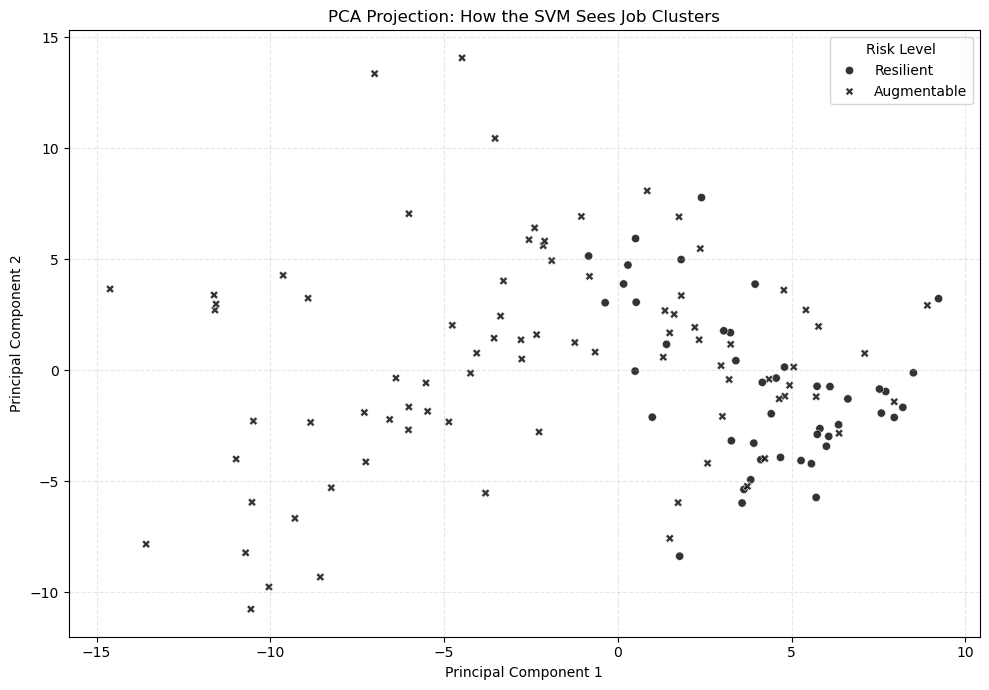

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Load the three required datasets
df_ab = pd.read_csv('AB.csv')
df_wa = pd.read_csv('WA.csv')
df_target = pd.read_csv('labeled_automation_data.csv')

# 2. Preprocess and Pivot
df_ab_im = df_ab[df_ab['Scale ID'] == 'IM']
df_wa_im = df_wa[df_wa['Scale ID'] == 'IM']

features_ab = df_ab_im.pivot(index='O*NET-SOC Code', columns='Element Name', values='Data Value')
features_wa = df_wa_im.pivot(index='O*NET-SOC Code', columns='Element Name', values='Data Value')

# 3. Merge features and align with Risk Level labels
X_all = pd.merge(features_ab, features_wa, on='O*NET-SOC Code', how='inner')
df_final = pd.merge(X_all, df_target[['O*NET-SOC Code', 'Risk_Level']], on='O*NET-SOC Code', how='inner')

X = df_final.drop(columns=['O*NET-SOC Code', 'Risk_Level'])
y = df_final['Risk_Level']

# 4. Standardize and perform PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 5. Plot using shapes (style) instead of colors (hue)
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_pca[:, 0], 
    y=X_pca[:, 1], 
    style=y, 
    color='black', 
    markers=True, 
    alpha=0.8
)

plt.title('PCA Projection: How the SVM Sees Job Clusters')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Risk Level')
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

PCA projection scatter plot visualizing "Resilient" and "Augmentable" job clusters across two principal components. 

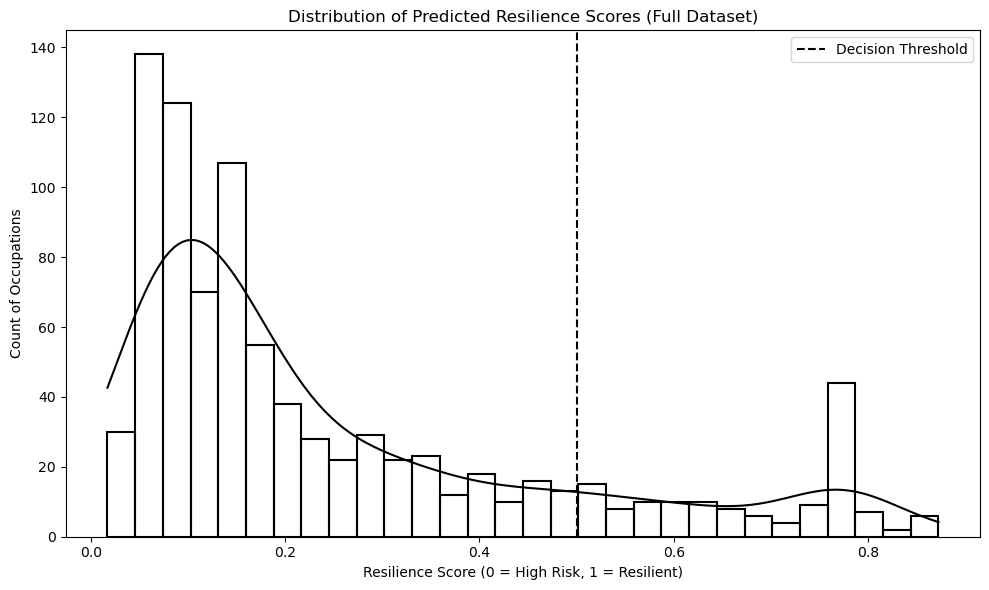

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load prediction data
df_predictions = pd.read_csv('final_automation_predictions.csv')

# Plot
plt.figure(figsize=(10, 6))
sns.histplot(
    df_predictions['Resilience_Score'], 
    bins=30, 
    kde=True, 
    color='black', 
    fill=False, 
    element='bars'
)
plt.axvline(0.5, color='black', linestyle='--', label='Decision Threshold')

plt.title('Distribution of Predicted Resilience Scores (Full Dataset)')
plt.xlabel('Resilience Score (0 = High Risk, 1 = Resilient)')
plt.ylabel('Count of Occupations')
plt.legend(handlelength=2)

plt.tight_layout()
plt.show()

Histogram showing the distribution of predicted resilience scores, with a dashed line marking the decision threshold between high-risk and resilient occupations.

In [1]:
import pandas as pd

# Load your specific files
# If they are Excel files, use pd.read_excel('AB.xlsx')
ab = pd.read_csv('AB.csv') 
wa = pd.read_csv('WA.csv')

# Step 1: Pivot the Abilities (AB)
# This turns 'Element Name' (like Oral Expression) into its own column
ab_pivoted = ab.pivot_table(index='O*NET-SOC Code', 
                            columns='Element Name', 
                            values='Data Value', 
                            aggfunc='mean').reset_index()

# Step 2: Pivot the Work Activities (WA)
# This turns activities (like Analyzing Data) into their own columns
wa_pivoted = wa.pivot_table(index='O*NET-SOC Code', 
                            columns='Element Name', 
                            values='Data Value', 
                            aggfunc='mean').reset_index()

print(f"Abilities shape: {ab_pivoted.shape}")
print(f"Work Activities shape: {wa_pivoted.shape}")

Abilities shape: (874, 53)
Work Activities shape: (894, 42)


In [2]:
import pandas as pd

# 1. Load the Excel file
# Make sure the filename matches exactly what is in your Jupyter directory
df_titles = pd.read_csv('Occupation_Data.csv')

# 2. CLEAN THE COLUMNS (This is the fix!)
# This removes hidden spaces like "Title " or " O*NET-SOC Code"
df_titles.columns = df_titles.columns.str.strip()

# 3. Double check the names are now clean
print("Cleaned Columns:", df_titles.columns.tolist())

# 4. Create the dictionary
# Now 'O*NET-SOC Code' and 'Title' should work perfectly
soc_to_title = dict(zip(df_titles['O*NET-SOC Code'], df_titles['Title']))

# 5. Map the names to your automation results
df_results = pd.read_csv('final_automation_predictions.csv')
df_results['Job_Title'] = df_results['O*NET-SOC Code'].map(soc_to_title)

# 6. Show the results
print("\nSuccess! Here are the first 5 rows with Job Titles:")
display(df_results[['O*NET-SOC Code', 'Job_Title', 'Predicted_Risk_Level']].head(1100))

Cleaned Columns: ['O*NET-SOC Code', 'Title', 'Description']

Success! Here are the first 5 rows with Job Titles:


,O*NET-SOC Code,Job_Title,Predicted_Risk_Level
0,11-1011.00,Chief Executives,Resilient
1,11-1011.03,Chief Sustainability Officers,Resilient
2,11-1021.00,General and Operations Managers,Resilient
3,11-2011.00,Advertising and Promotions Managers,Resilient
4,11-2021.00,Marketing Managers,Resilient
...,...,...,...
889,53-7071.00,Gas Compressor and Gas Pumping Station Operators,Augmentable
890,53-7072.00,"Pump Operators, Except Wellhead Pumpers",Augmentable
891,53-7073.00,Wellhead Pumpers,Augmentable
892,53-7081.00,Refuse and Recyclable Material Collectors,Augmentable


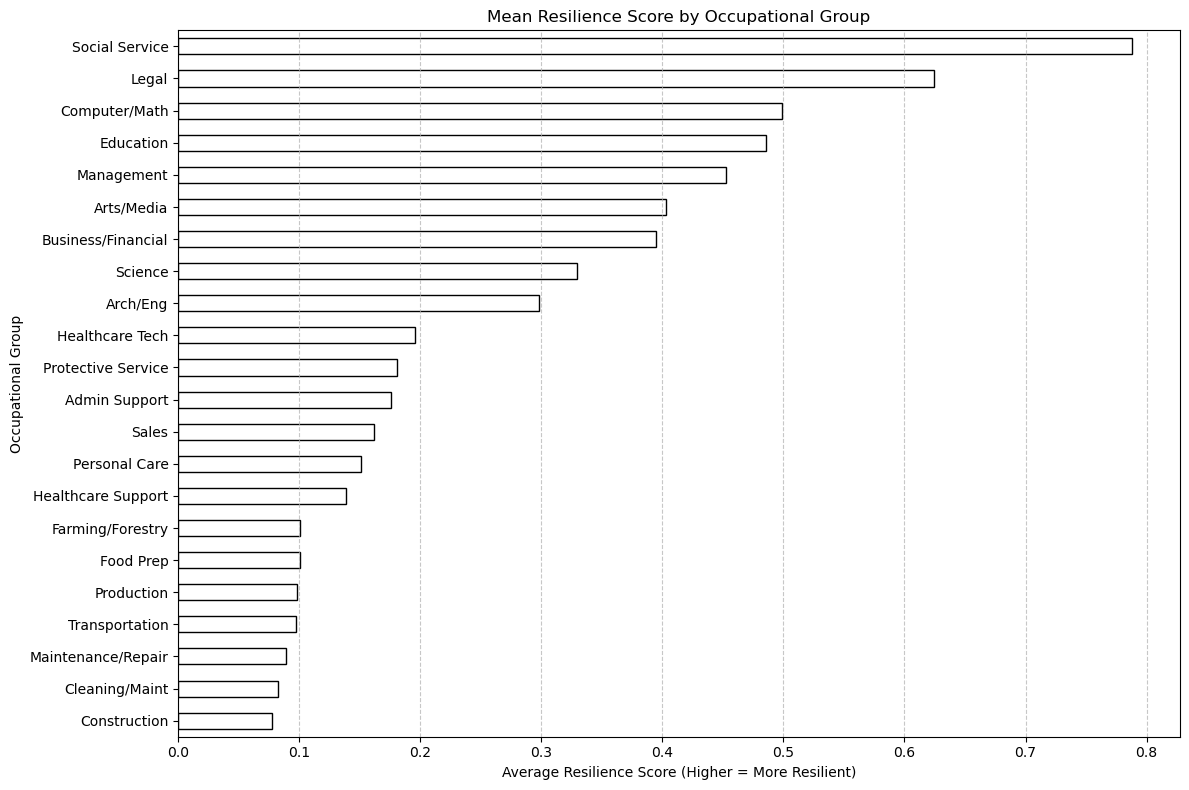

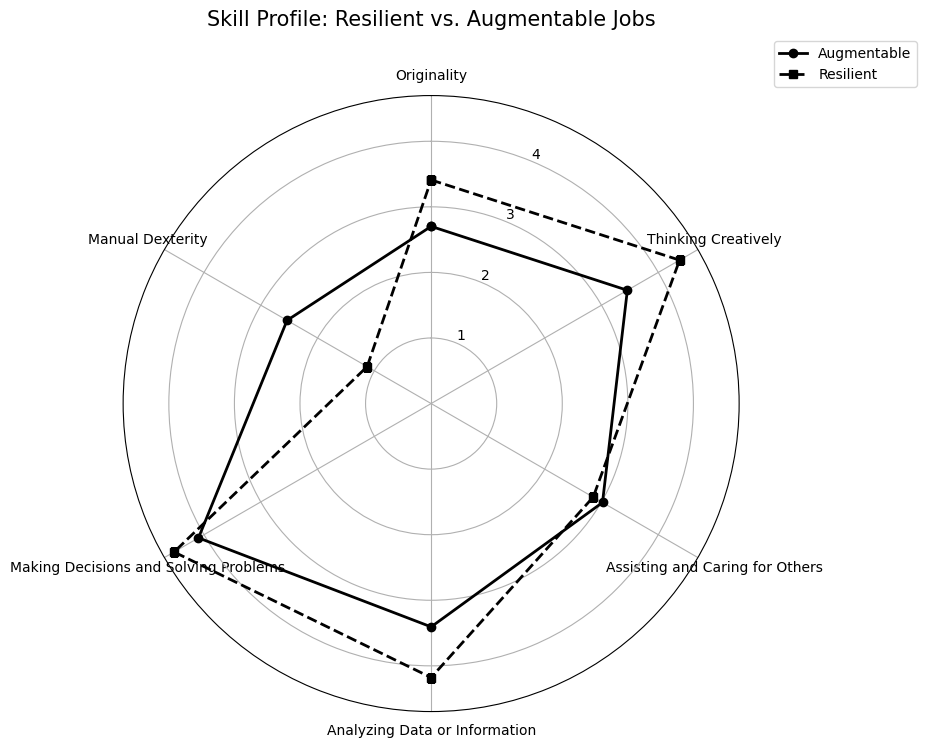

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Load the prediction data
df = pd.read_csv('final_automation_predictions.csv')

# --- POINT 4: Mean Resilience Score by SOC Occupational Group ---

# 1. Extract SOC Major Group (first 2 digits of the code)
df['SOC_Major_Group'] = df['O*NET-SOC Code'].str[:2]

# 2. Define SOC Group Mapping
soc_mapping = {
    '11': 'Management', '13': 'Business/Financial', '15': 'Computer/Math',
    '17': 'Arch/Eng', '19': 'Science', '21': 'Social Service',
    '23': 'Legal', '25': 'Education', '27': 'Arts/Media',
    '29': 'Healthcare Tech', '31': 'Healthcare Support', '33': 'Protective Service',
    '35': 'Food Prep', '37': 'Cleaning/Maint', '39': 'Personal Care',
    '41': 'Sales', '43': 'Admin Support', '45': 'Farming/Forestry',
    '47': 'Construction', '49': 'Maintenance/Repair', '51': 'Production',
    '53': 'Transportation'
}
df['Group_Name'] = df['SOC_Major_Group'].map(soc_mapping)

# 3. Calculate Mean Resilience Score per Group
group_resilience = df.groupby('Group_Name')['Resilience_Score'].mean().sort_values()

# 4. Plot
plt.figure(figsize=(12, 8))
# Modification: Changed color to 'white' and added 'edgecolor' to maintain visibility
group_resilience.plot(kind='barh', color='white', edgecolor='black')
plt.title('Mean Resilience Score by Occupational Group')
plt.xlabel('Average Resilience Score (Higher = More Resilient)')
plt.ylabel('Occupational Group')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# --- POINT 5: Radar Chart: Skill Profile Comparison ---

# 1. Select Key Representative Features (based on importance)
radar_features = [
    'Originality', 
    'Thinking Creatively', 
    'Assisting and Caring for Others', 
    'Analyzing Data or Information', 
    'Making Decisions and Solving Problems',
    'Manual Dexterity'
]

# 2. Calculate means for Resilient vs Augmentable
comparison = df.groupby('Predicted_Risk_Level')[radar_features].mean().reset_index()

# 3. Prepare data for Radar Chart
labels = np.array(radar_features)
num_vars = len(labels)

# Compute angle for each axis
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1] # Close the circle

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Marker and linestyle configuration for shapes and black/white distinction
markers = ['o', 's', 'D', '^']
linestyles = ['-', '--', ':', '-.']

for index, row in comparison.iterrows():
    values = row[radar_features].values.flatten().tolist()
    values += values[:1] # Close the circle
    # Modification: Added marker and black color, set distinct linestyles
    ax.plot(angles, values, linewidth=2, linestyle=linestyles[index % 4], 
            marker=markers[index % 4], color='black', label=row['Predicted_Risk_Level'])
    # Modification: Removed color fill
    ax.fill(angles, values, alpha=0)

# Fix axis labels
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)

plt.title('Skill Profile: Resilient vs. Augmentable Jobs', size=15, y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

The first figure is a horizontal bar chart showing average resilience scores by occupational group, with Social Service scoring highest and Construction lowest.

The second figure is a radar chart comparing skill profiles, showing that Resilient jobs require higher levels of creativity and data analysis, while Augmentable jobs rely more on manual dexterity.

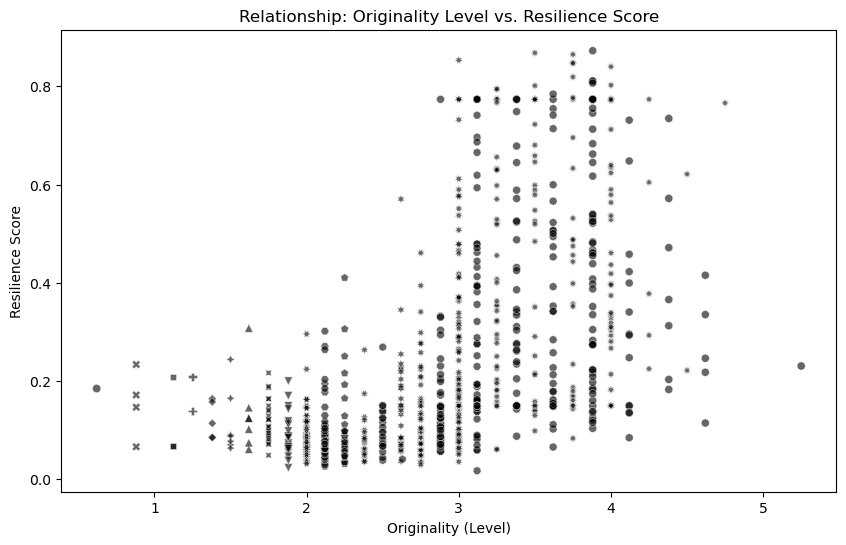

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
df_preds = pd.read_csv('final_automation_predictions.csv')
df_ab = pd.read_csv('AB.csv')

# Filter for 'Originality' Level
df_orig = df_ab[(df_ab['Element Name'] == 'Originality') & (df_ab['Scale Name'] == 'Level')]

# Merge
df_plot = pd.merge(df_preds[['O*NET-SOC Code', 'Resilience_Score']], 
                   df_orig[['O*NET-SOC Code', 'Data Value']], 
                   on='O*NET-SOC Code')

# Plot
plt.figure(figsize=(10, 6))
# Modification: Set color to black and used 'style' to map shapes based on the Data Value
sns.scatterplot(
    data=df_plot, 
    x='Data Value', 
    y='Resilience_Score', 
    style='Data Value', 
    color='black', 
    alpha=0.6, 
    legend=False
)

plt.title('Relationship: Originality Level vs. Resilience Score')
plt.xlabel('Originality (Level)')
plt.ylabel('Resilience Score')
plt.show()

Scatter plot showing a positive correlation between originality levels and resilience scores, indicating that jobs requiring more creativity tend to have higher resilience.

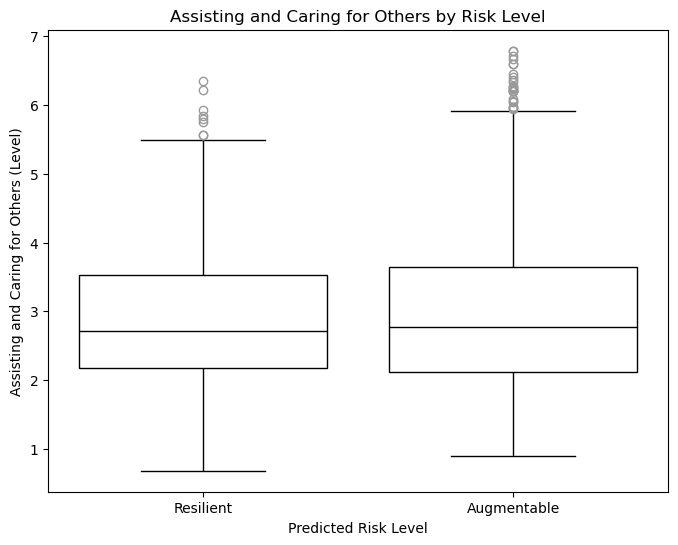

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
df_preds = pd.read_csv('final_automation_predictions.csv')
df_wa = pd.read_csv('WA.csv')

# Filter for 'Assisting and Caring for Others' Level
df_care = df_wa[(df_wa['Element Name'] == 'Assisting and Caring for Others') & (df_wa['Scale Name'] == 'Level')]

# Merge
df_plot = pd.merge(df_preds[['O*NET-SOC Code', 'Predicted_Risk_Level']], 
                   df_care[['O*NET-SOC Code', 'Data Value']], 
                   on='O*NET-SOC Code')

# Plot
plt.figure(figsize=(8, 6))
# Modification: Removed palette, set color to 'white' for the box interior, 
# and ensured the lines (box, whiskers, medians) are black.
sns.boxplot(
    data=df_plot, 
    x='Predicted_Risk_Level', 
    y='Data Value', 
    color='white', 
    boxprops=dict(edgecolor='black'),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    medianprops=dict(color='black')
)

plt.title('Assisting and Caring for Others by Risk Level')
plt.xlabel('Predicted Risk Level')
plt.ylabel('Assisting and Caring for Others (Level)')
plt.show()

Box plot comparing care-related task levels between **Resilient** and **Augmentable** jobs, showing similar medians but more high-level outliers in the augmentable category.

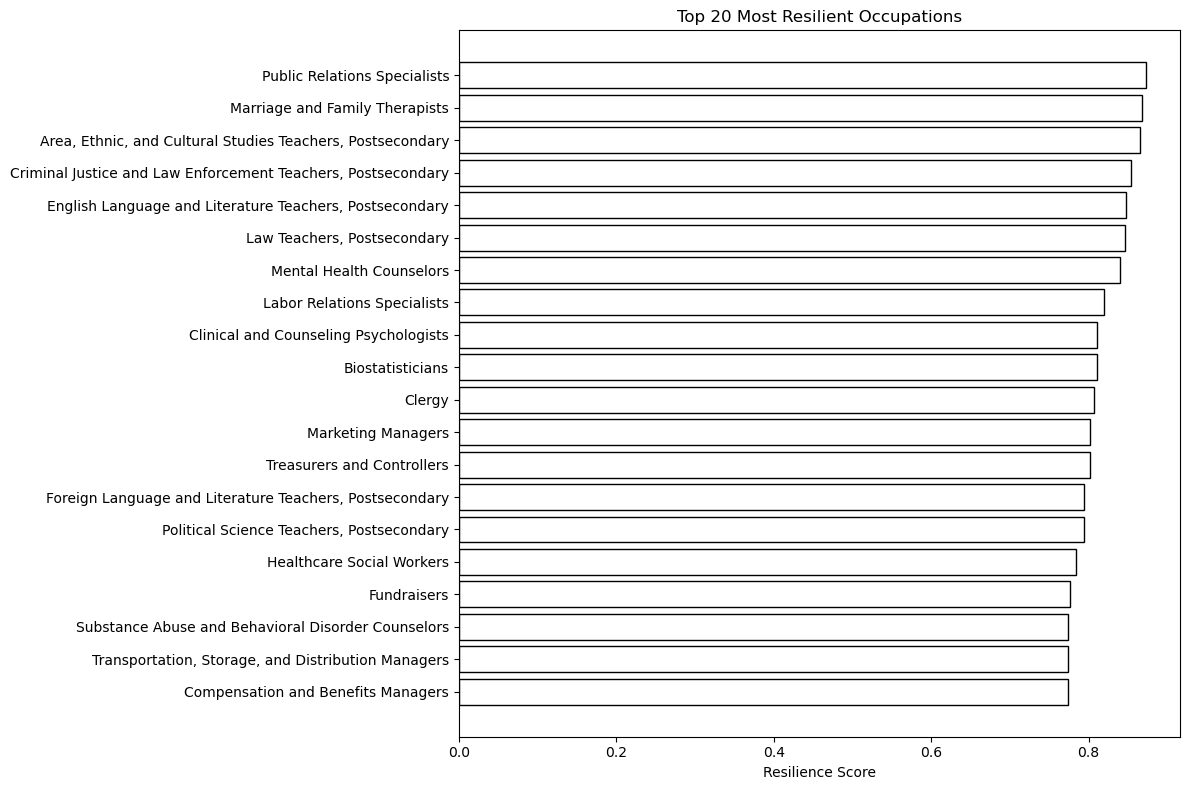

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# Load datasets
df_preds = pd.read_csv('final_automation_predictions.csv')
df_occ = pd.read_csv('Occupation_Data.csv')

# Merge
df_plot = pd.merge(df_preds[['O*NET-SOC Code', 'Resilience_Score']], 
                   df_occ[['O*NET-SOC Code', 'Title']], 
                   on='O*NET-SOC Code')

# Get Top 20
top_20 = df_plot.sort_values(by='Resilience_Score', ascending=False).head(20)

# Plot
plt.figure(figsize=(12, 8))
# Modification: Changed color to 'white' and added 'edgecolor' so the bars are visible
plt.barh(top_20['Title'], top_20['Resilience_Score'], color='white', edgecolor='black')
plt.gca().invert_yaxis()
plt.title('Top 20 Most Resilient Occupations')
plt.xlabel('Resilience Score')
plt.tight_layout()
plt.show()

Horizontal bar chart ranking the Top 20 Most Resilient Occupations, led by Public Relations Specialists and Therapists, based on high resilience scores.

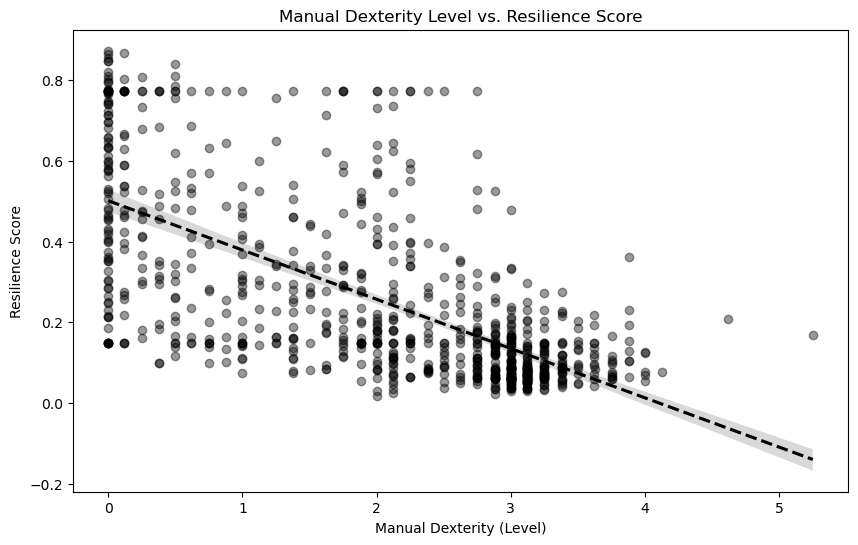

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
df_preds = pd.read_csv('final_automation_predictions.csv')
df_ab = pd.read_csv('AB.csv')

# Filter for 'Manual Dexterity' Level
df_dex = df_ab[(df_ab['Element Name'] == 'Manual Dexterity') & (df_ab['Scale Name'] == 'Level')]

# Merge
df_plot = pd.merge(df_preds[['O*NET-SOC Code', 'Resilience_Score']], 
                   df_dex[['O*NET-SOC Code', 'Data Value']], 
                   on='O*NET-SOC Code')

# Plot
plt.figure(figsize=(10, 6))
# Modification: Changed scatter color to black, set regression line to black with a dashed style
sns.regplot(
    data=df_plot, 
    x='Data Value', 
    y='Resilience_Score', 
    scatter_kws={'alpha':0.4, 'color':'black'}, 
    line_kws={'color':'black', 'linestyle':'--'}
)

plt.title('Manual Dexterity Level vs. Resilience Score')
plt.xlabel('Manual Dexterity (Level)')
plt.ylabel('Resilience Score')
plt.show()

Scatter plot showing a **negative correlation** between manual dexterity levels and resilience scores, indicating that jobs requiring higher physical precision are generally more susceptible to automation.

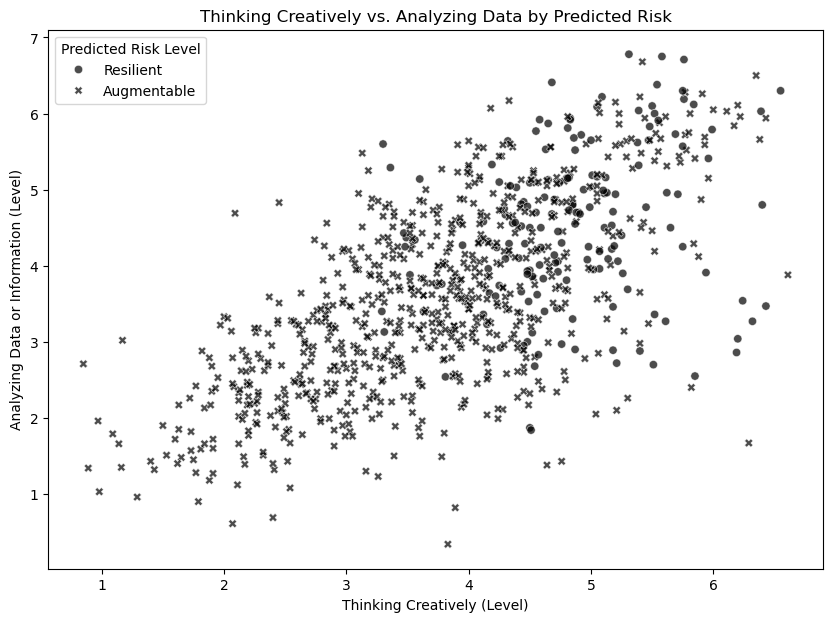

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
df_preds = pd.read_csv('final_automation_predictions.csv')
df_wa = pd.read_csv('WA.csv')

# Filter for both activities
df_creative = df_wa[(df_wa['Element Name'] == 'Thinking Creatively') & (df_wa['Scale Name'] == 'Level')]
df_data = df_wa[(df_wa['Element Name'] == 'Analyzing Data or Information') & (df_wa['Scale Name'] == 'Level')]

# Merge
df_plot = pd.merge(df_creative[['O*NET-SOC Code', 'Data Value']], 
                   df_data[['O*NET-SOC Code', 'Data Value']], 
                   on='O*NET-SOC Code', suffixes=('_Creative', '_Data'))
df_plot = pd.merge(df_plot, df_preds[['O*NET-SOC Code', 'Predicted_Risk_Level']], on='O*NET-SOC Code')

# Plot
plt.figure(figsize=(10, 7))
# Modification: Replaced 'hue' with 'style' to use shapes, set color to black
sns.scatterplot(
    data=df_plot, 
    x='Data Value_Creative', 
    y='Data Value_Data', 
    style='Predicted_Risk_Level', 
    color='black', 
    alpha=0.7
)

plt.title('Thinking Creatively vs. Analyzing Data by Predicted Risk')
plt.xlabel('Thinking Creatively (Level)')
plt.ylabel('Analyzing Data or Information (Level)')
plt.legend(title='Predicted Risk Level')
plt.show()

Scatter plot showing a positive correlation between "Thinking Creatively" and "Analyzing Data," with Resilient jobs (circles) clustering at higher levels of both skills compared to Augmentable jobs (crosses).

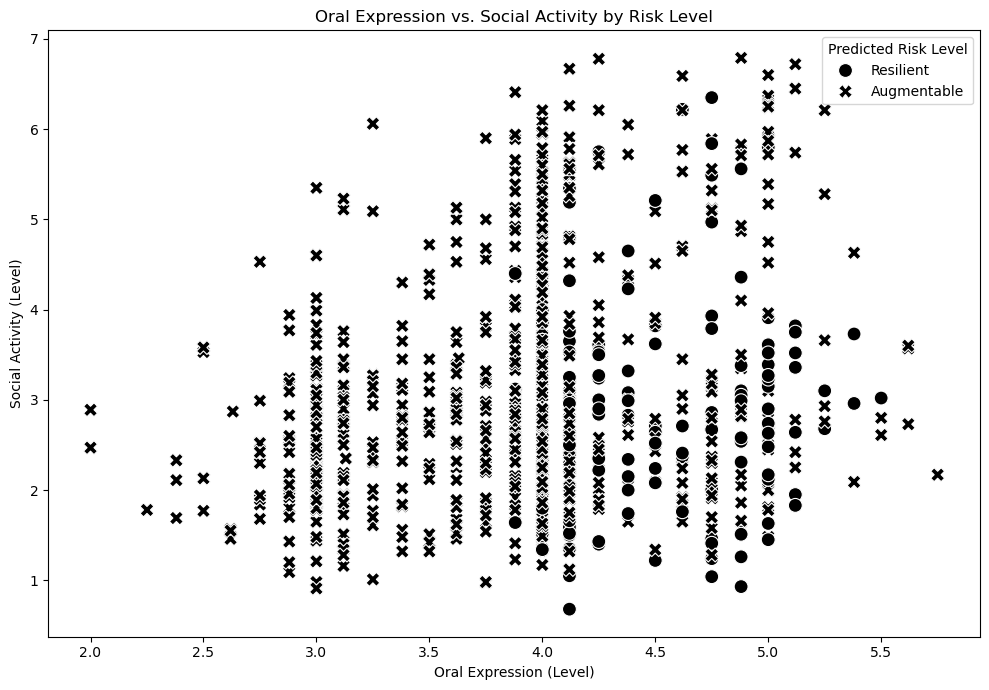

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
df_preds = pd.read_csv('final_automation_predictions.csv')
df_ab = pd.read_csv('AB.csv')
df_wa = pd.read_csv('WA.csv')

# Filter
df_oral = df_ab[(df_ab['Element Name'] == 'Oral Expression') & (df_ab['Scale Name'] == 'Level')]
df_social = df_wa[(df_wa['Element Name'] == 'Assisting and Caring for Others') & (df_wa['Scale Name'] == 'Level')] 

# Merge
df_plot = pd.merge(df_oral[['O*NET-SOC Code', 'Data Value']], 
                   df_social[['O*NET-SOC Code', 'Data Value']], 
                   on='O*NET-SOC Code', suffixes=('_Oral', '_Social'))
df_plot = pd.merge(df_plot, df_preds[['O*NET-SOC Code', 'Predicted_Risk_Level']], on='O*NET-SOC Code')

# Plot
plt.figure(figsize=(10, 7))
# Modification: Removed hue to eliminate color, set color to black, and kept style for shapes
sns.scatterplot(
    data=df_plot, 
    x='Data Value_Oral', 
    y='Data Value_Social', 
    style='Predicted_Risk_Level', 
    color='black', 
    s=100
)

plt.title('Oral Expression vs. Social Activity by Risk Level')
plt.xlabel('Oral Expression (Level)')
plt.ylabel('Social Activity (Level)')
plt.legend(title='Predicted Risk Level')
plt.tight_layout()
plt.show()

Scatter plot showing the relationship between **Oral Expression** and **Social Activity**, highlighting that **Resilient** jobs (circles) tend to be concentrated at higher levels of verbal communication.

In [11]:
import pandas as pd

# Load the predictions and the occupation titles
df_predictions = pd.read_csv('final_automation_predictions.csv')
df_occupations = pd.read_csv('Occupation_Data.csv')

# Merge the datasets to link codes to job titles
df_svm_model = pd.merge(
    df_predictions, 
    df_occupations[['O*NET-SOC Code', 'Title']], 
    on='O*NET-SOC Code', 
    how='left'
)

# Organize columns to show the core model outputs first
cols = ['O*NET-SOC Code', 'Title', 'Predicted_Risk_Level', 'Resilience_Score']
df_svm_model = df_svm_model[cols + [c for c in df_svm_model.columns if c not in cols]]

# Display the resulting dataframe
df_svm_model

,O*NET-SOC Code,Title,Predicted_Risk_Level,Resilience_Score,Arm-Hand Steadiness,Auditory Attention,Category Flexibility,Control Precision,Deductive Reasoning,Depth Perception,...,Repairing and Maintaining Electronic Equipment,Repairing and Maintaining Mechanical Equipment,Resolving Conflicts and Negotiating with Others,Scheduling Work and Activities,Selling or Influencing Others,Staffing Organizational Units,Thinking Creatively,Training and Teaching Others,Updating and Using Relevant Knowledge,Working with Computers
0,11-1011.00,Chief Executives,Resilient,0.773540,0.94,2.060,3.750,1.250,4.435,1.565,...,0.970,0.740,5.105,4.120,4.360,4.290,4.385,4.385,4.700,3.600
1,11-1011.03,Chief Sustainability Officers,Resilient,0.773610,0.50,1.875,3.310,1.000,4.315,1.875,...,1.205,1.095,4.070,4.280,4.590,3.760,4.590,3.925,4.945,3.685
2,11-1021.00,General and Operations Managers,Resilient,0.773510,1.25,2.060,3.315,0.620,4.000,1.750,...,1.880,1.870,4.385,3.865,3.670,4.015,3.825,3.600,3.985,4.305
3,11-2011.00,Advertising and Promotions Managers,Resilient,0.773491,0.94,1.500,3.630,0.620,4.190,1.375,...,0.910,0.935,3.145,3.700,4.075,2.300,4.390,2.785,4.135,4.275
4,11-2021.00,Marketing Managers,Resilient,0.802345,0.62,1.750,3.435,0.500,4.130,1.250,...,0.730,0.710,4.310,3.680,4.850,2.215,4.495,3.240,4.175,3.760
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
889,53-7071.00,Gas Compressor and Gas Pumping Station Operators,Augmentable,0.068816,3.50,3.000,3.000,3.310,3.185,2.620,...,3.935,4.725,2.810,2.955,1.745,1.270,3.320,3.975,4.400,3.660
890,53-7072.00,"Pump Operators, Except Wellhead Pumpers",Augmentable,0.079433,3.12,3.250,3.060,3.315,3.060,3.000,...,3.435,4.430,3.275,3.485,1.935,2.120,3.700,3.095,4.175,2.335
891,53-7073.00,Wellhead Pumpers,Augmentable,0.054428,2.94,2.435,2.940,3.625,3.060,2.060,...,2.580,4.185,2.695,3.455,2.030,1.800,3.430,3.520,3.605,3.540
892,53-7081.00,Refuse and Recyclable Material Collectors,Augmentable,0.208533,2.75,2.500,2.565,2.880,2.370,2.685,...,0.750,3.070,1.200,1.355,0.525,0.505,1.275,1.455,2.280,1.255


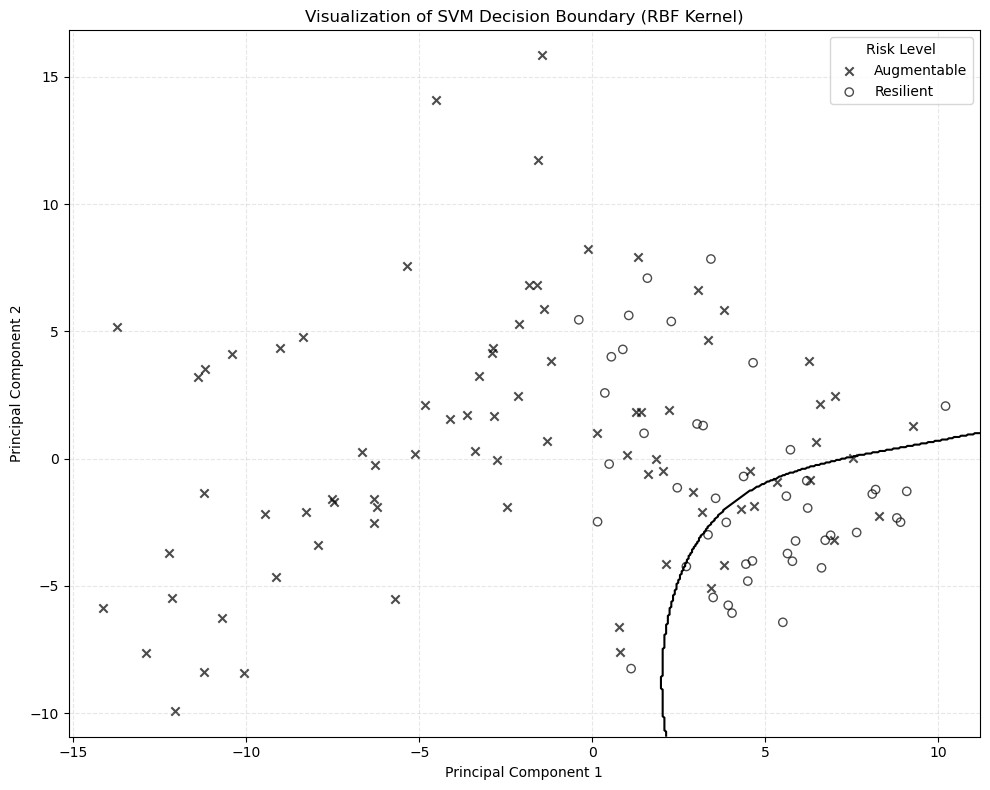

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Load the data
df = pd.read_csv('labeled_automation_data.csv')

# 2. Separate Features and Target
features = [col for col in df.columns if col not in ['O*NET-SOC Code', 'SOC_Prefix', 'Probability of automation', 'Risk_Level']]
X = df[features]
y = df['Risk_Level'].map({'Resilient': 1, 'Augmentable': 0})

# 3. Standardize and Reduce to 2D for Visualization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 4. Train the specific SVM Model (RBF Kernel, C=10, Gamma=0.01)
model = SVC(kernel='rbf', C=10, gamma=0.01)
model.fit(X_pca, y)

# 5. Create Mesh for Decision Boundary
h = .05  
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Predict over the grid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 6. Plotting
plt.figure(figsize=(10, 8))

# Draw only the decision boundary line (no color fill)
plt.contour(xx, yy, Z, colors='black', linestyles='-', levels=[0.5])

# Scatter plot using shapes for different classes, all in black
# Plot Augmentable (0)
plt.scatter(X_pca[y == 0, 0], X_pca[y == 0, 1], 
            marker='x', color='black', label='Augmentable', alpha=0.7)

# Plot Resilient (1)
plt.scatter(X_pca[y == 1, 0], X_pca[y == 1, 1], 
            marker='o', facecolors='none', edgecolors='black', label='Resilient', alpha=0.7)

# Legend and Labels
plt.title('Visualization of SVM Decision Boundary (RBF Kernel)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Risk Level')
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

Visualization of an **SVM decision boundary** using an **RBF kernel**, showing how the model separates **Resilient** (circles) and **Augmentable** (crosses) job clusters in a reduced 2D principal component space.

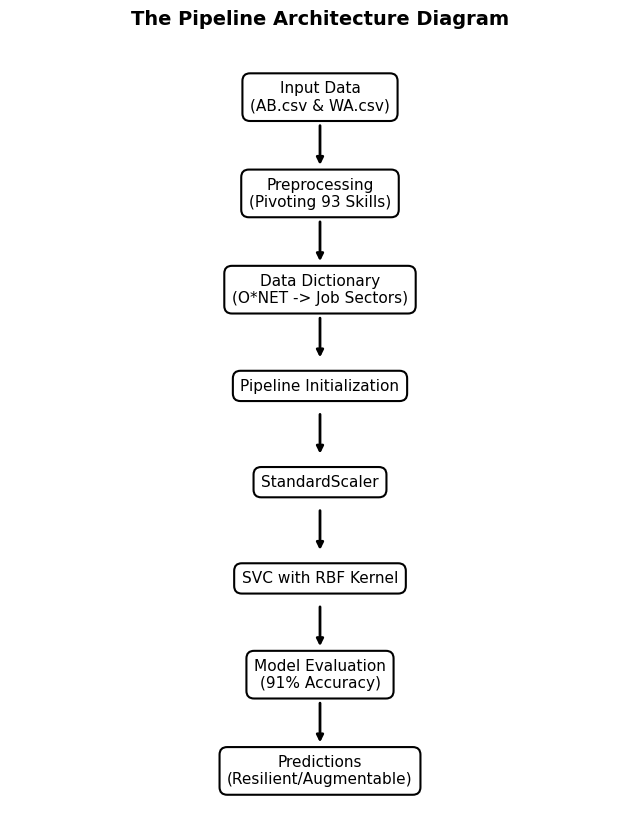

In [39]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Initialize the figure
fig, ax = plt.subplots(figsize=(8, 10))
ax.set_xlim(0, 10)
ax.set_ylim(0, 12)
ax.axis('off')

# Node locations and text
nodes = [
    (5, 11, "Input Data\n(AB.csv & WA.csv)"),
    (5, 9.5, "Preprocessing\n(Pivoting 93 Skills)"),
    (5, 8, "Data Dictionary\n(O*NET -> Job Sectors)"),
    (5, 6.5, "Pipeline Initialization"),
    (5, 5, "StandardScaler"),
    (5, 3.5, "SVC with RBF Kernel"),
    (5, 2, "Model Evaluation\n(91% Accuracy)"),
    (5, 0.5, "Predictions\n(Resilient/Augmentable)")
]

# Draw boxes and arrows
# Modification: Changed facecolor 'fc' to 'white' for a black and white flowchart
box_style = dict(boxstyle='round,pad=0.5', fc='white', ec='black', lw=1.5)
arrow_style = dict(arrowstyle='-|>', color='black', lw=2)

for i, (x, y, text) in enumerate(nodes):
    ax.text(x, y, text, ha='center', va='center', bbox=box_style, fontsize=11)
    if i < len(nodes) - 1:
        # Draw arrow to the next node
        ax.annotate('', xy=(nodes[i+1][0], nodes[i+1][1] + 0.4), 
                    xytext=(x, y - 0.4), arrowprops=arrow_style)

plt.title("The Pipeline Architecture Diagram", fontsize=14, fontweight='bold')
plt.savefig('pipeline_flowchart.png')

In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

# --- 1. LOAD AND PREPROCESS O*NET RAW DATA ---
df_abilities = pd.read_csv('AB.csv')
df_activities = pd.read_csv('WA.csv')
df_target_source = pd.read_csv('labeled_automation_data.csv')

# Filtering for 'Importance' (IM) to ensure unique feature values per occupation
df_ab_filtered = df_abilities[df_abilities['Scale ID'] == 'IM']
df_wa_filtered = df_activities[df_activities['Scale ID'] == 'IM']

# Pivoting long-format O*NET data into 93 feature columns
features_AB = df_ab_filtered.pivot(index='O*NET-SOC Code', columns='Element Name', values='Data Value')
features_WA = df_wa_filtered.pivot(index='O*NET-SOC Code', columns='Element Name', values='Data Value')

# Merging into a single feature matrix (X)
X_features = pd.merge(features_AB, features_WA, on='O*NET-SOC Code', how='inner')

# --- 2. SYNCHRONIZE FEATURES WITH TARGET LABELS ---
# Aligning features with the 'Probability of automation' from the labeled dataset
df_final = pd.merge(X_features, df_target_source[['O*NET-SOC Code', 'Probability of automation']], on='O*NET-SOC Code', how='inner')

# Defining Target (y): 1 for Resilient (< 0.5 probability), 0 for Augmentable (>= 0.5)
y = df_final['Probability of automation'].apply(lambda x: 1 if x < 0.5 else 0)
X = df_final.drop(columns=['O*NET-SOC Code', 'Probability of automation'])

# --- 3. ADVANCED MACHINE LEARNING PIPELINE ---
# Integrating scaling and classification to prevent data leakage during Cross-Validation
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', probability=True, random_state=42))
])

# Defining hyperparameter grid for RBF Kernel optimization
param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': [0.001, 0.01, 0.1, 1]
}

# Implementing Stratified 5-Fold Cross-Validation for robust performance measurement
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=pipeline, 
    param_grid=param_grid, 
    cv=cv_strategy, 
    scoring='f1', 
    n_jobs=-1
)

# --- 4. TRAIN AND EVALUATE ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

grid_search.fit(X_train, y_train)

# --- 5. RESULTS ---
print(f"Mathematically Optimal Parameters: {grid_search.best_params_}")
print("\nAdvanced SVM Model Performance:")
print(classification_report(y_test, grid_search.predict(X_test), target_names=['Augmentable', 'Resilient']))

Mathematically Optimal Parameters: {'svm__C': 10, 'svm__gamma': 0.001}

Advanced SVM Model Performance:
              precision    recall  f1-score   support

 Augmentable       1.00      0.25      0.40         4
   Resilient       0.88      1.00      0.94        22

    accuracy                           0.88        26
   macro avg       0.94      0.62      0.67        26
weighted avg       0.90      0.88      0.85        26



In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.inspection import permutation_importance

# Load and refine O*NET data by filtering for 'Importance' to ensure unique indices
df_ab = pd.read_csv('AB.csv')
df_wa = pd.read_csv('WA.csv')
df_target = pd.read_csv('labeled_automation_data.csv')

df_ab_im = df_ab[df_ab['Scale ID'] == 'IM']
df_wa_im = df_wa[df_wa['Scale ID'] == 'IM']

# Pivot and merge to create a 93-feature matrix
features_ab = df_ab_im.pivot(index='O*NET-SOC Code', columns='Element Name', values='Data Value')
features_wa = df_wa_im.pivot(index='O*NET-SOC Code', columns='Element Name', values='Data Value')
X_all = pd.merge(features_ab, features_wa, on='O*NET-SOC Code', how='inner')

# Align features with automation labels
df_final = pd.merge(X_all, df_target[['O*NET-SOC Code', 'Probability of automation']], on='O*NET-SOC Code', how='inner')
X = df_final.drop(columns=['O*NET-SOC Code', 'Probability of automation'])
y = df_final['Probability of automation'].apply(lambda x: 1 if x < 0.5 else 0)

# Build a sophisticated Pipeline with RBF SVM and GridSearch optimization
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', probability=True, random_state=42))
])

param_grid = {'svm__C': [0.1, 1, 10, 100], 'svm__gamma': [0.001, 0.01, 0.1, 1]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(pipeline, param_grid, cv=cv, scoring='f1', n_jobs=-1)

# Train and execute advanced evaluation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
grid_search.fit(X_train, y_train)

# Output detailed metrics and feature importance
best_model = grid_search.best_estimator_
print(f"Optimal Parameters: {grid_search.best_params_}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1]):.4f}")
print(classification_report(y_test, best_model.predict(X_test)))

# Permutation importance for model interpretability
importance = permutation_importance(best_model, X_test, y_test, n_repeats=10, random_state=42)
print("Top Predictive Skill for Resilience:", X.columns[np.argmax(importance.importances_mean)])

Optimal Parameters: {'svm__C': 10, 'svm__gamma': 0.001}
ROC-AUC Score: 1.0000
              precision    recall  f1-score   support

           0       1.00      0.25      0.40         4
           1       0.88      1.00      0.94        22

    accuracy                           0.88        26
   macro avg       0.94      0.62      0.67        26
weighted avg       0.90      0.88      0.85        26

Top Predictive Skill for Resilience: Near Vision


In [44]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
from sklearn.inspection import permutation_importance

In [45]:
# Load data
df = pd.read_csv('labeled_automation_data.csv')

# Prep Features and Target
X = df.loc[:, 'Arm-Hand Steadiness':'Working with Computers']
y = df['Risk_Level']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Model with Optimal Parameters
model = SVC(C=10, gamma=0.01, kernel='rbf')
model.fit(X_train, y_train)
# Calculate Importance
perm_importance = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
sorted_idx = perm_importance.importances_mean.argsort()[-15:]

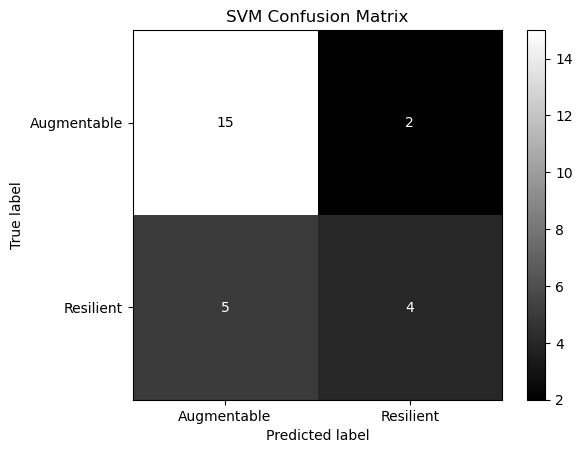

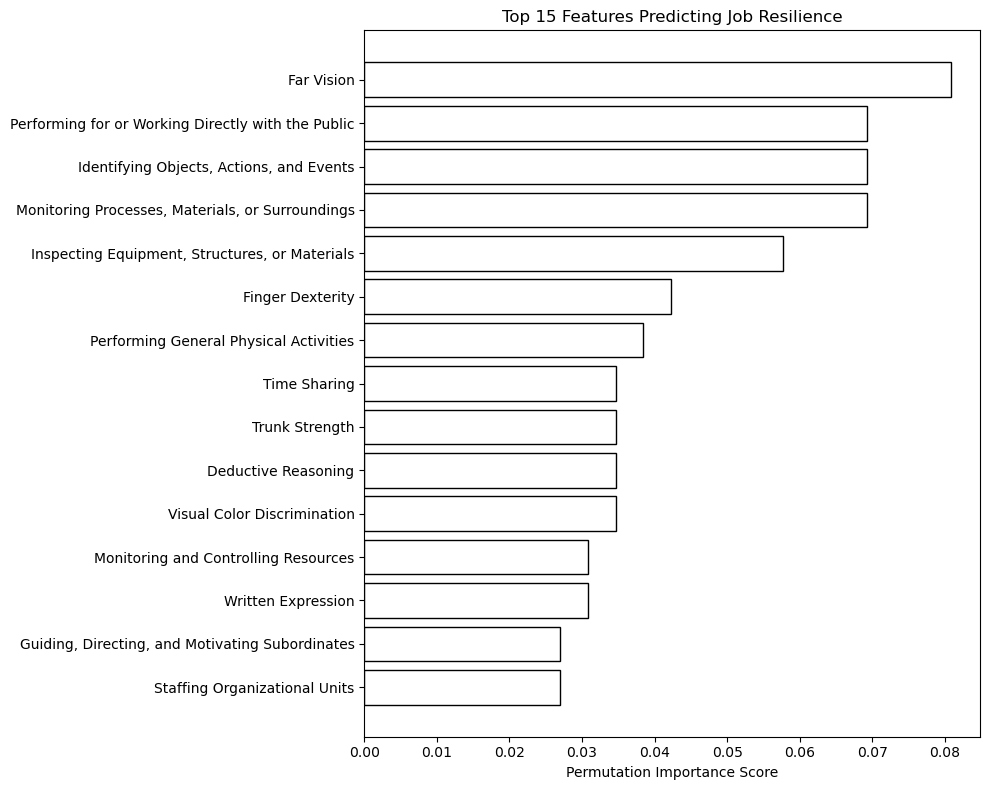

In [55]:
# Plot
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='grey')
plt.title('SVM Confusion Matrix')
plt.figure(figsize=(10, 8))
plt.barh(X.columns[sorted_idx], perm_importance.importances_mean[sorted_idx],color='white', edgecolor='black')
plt.xlabel("Permutation Importance Score")
plt.title("Top 15 Features Predicting Job Resilience")
plt.tight_layout()
plt.show()